# 📘 CIFAR-10 Image Classification
## ANN vs CNN - Architecture Comparison and Training Strategies

In this notebook I'm building image classification models on the CIFAR-10 dataset using both ANN and CNN, then comparing how they perform across different architectures and training strategies.

# 🧠 Problem Statement

The goal is to classify 32x32 color images into one of 10 categories using two different approaches:

1. **Artificial Neural Network (ANN)** - treats images as flattened vectors
2. **Convolutional Neural Network (CNN)** - uses spatial feature extraction

After building both, I'll compare accuracy, loss curves, and how different training strategies (dropout, batch normalization, data augmentation) affect the results.

## 📦 CIFAR-10 Classes: 
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

## Imports

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 📥 Load Dataset

CIFAR-10 is a standard benchmark dataset with 60,000 color images of size 32x32x3 across 10 classes.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Label shape:", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Label shape: (50000, 1)


## 🖼️ Visualize Sample Images

### Sample Images

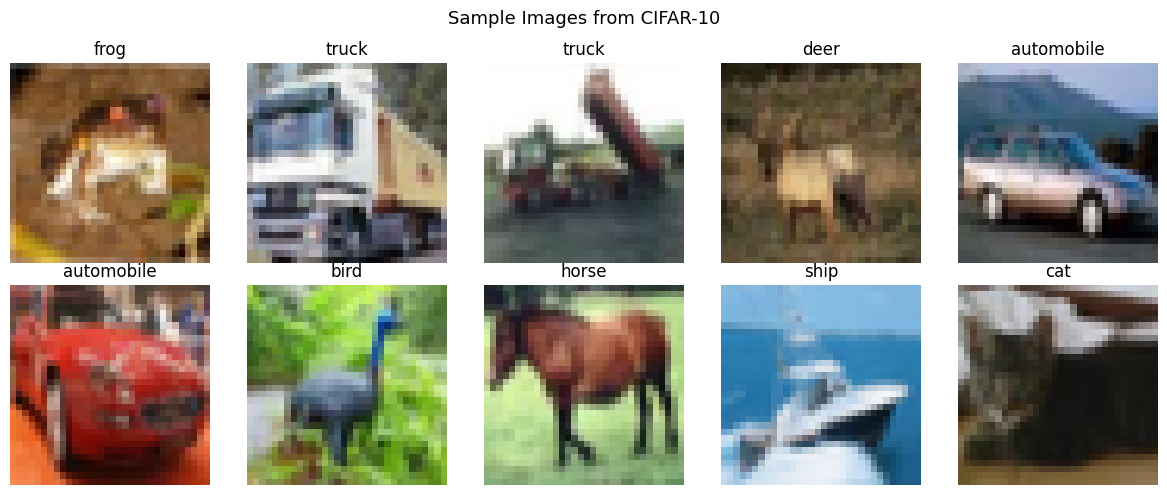

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("Sample Images from CIFAR-10", fontsize=13)
plt.tight_layout()
plt.show()

These are the 10 classes in CIFAR-10. The images are quite small (32x32) and some classes like cat, deer, and dog look visually similar which makes this a non-trivial classification task.

### Class Distribution

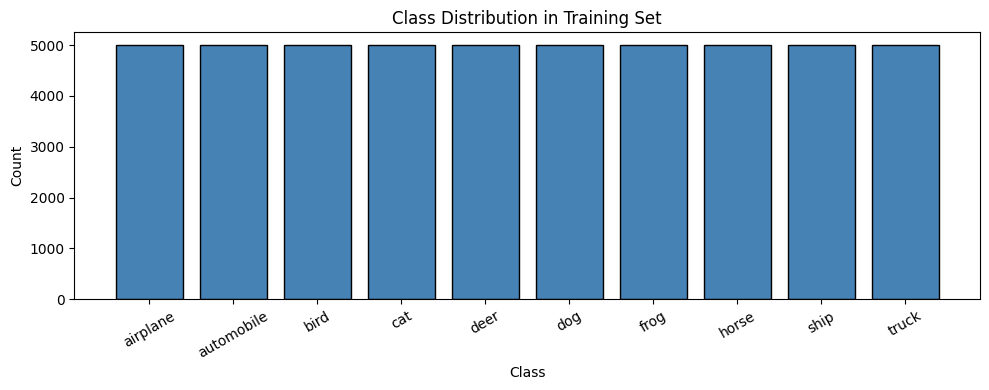

Samples per class:
  airplane: 5000
  automobile: 5000
  bird: 5000
  cat: 5000
  deer: 5000
  dog: 5000
  frog: 5000
  horse: 5000
  ship: 5000
  truck: 5000


In [ ]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Samples per class:")
for i, c in zip(unique, counts):
    print(f"  {class_names[i]}: {c}")

The dataset is perfectly balanced - each class has exactly 5000 training samples. This means I don't need to worry about class imbalance and can use standard accuracy as a fair metric.

### Pixel Intensity Distribution

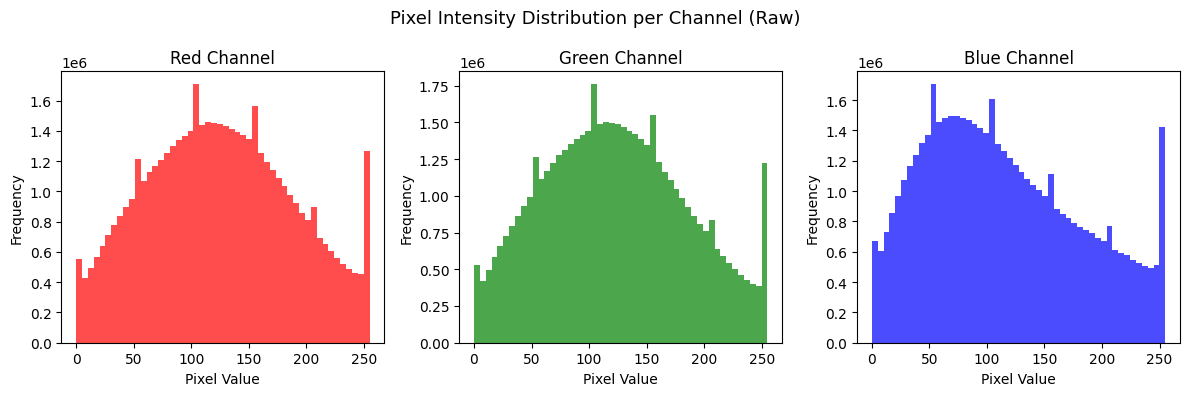

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
channels = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']

for i, (ch, col) in enumerate(zip(channels, colors)):
    axes[i].hist(x_train[:, :, :, i].ravel(), bins=50, color=col, alpha=0.7)
    axes[i].set_title(f"{ch} Channel")
    axes[i].set_xlabel("Pixel Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Pixel Intensity Distribution per Channel (Raw)", fontsize=13)
plt.tight_layout()
plt.show()

Pixel values are spread across the full 0-255 range across all three channels. The distributions look fairly similar between channels, which makes sense for a natural image dataset. This confirms normalization to [0,1] is the right preprocessing step.

## 🧹 Preprocessing

Normalizing pixel values from 0-255 to 0-1 helps with training stability. For the ANN I also flatten the images since it can't handle 3D input.

In [ ]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized range:", x_train_norm.min(), "-", x_train_norm.max())
print("Flattened shape for ANN:", x_train_flat.shape)
print("Original shape for CNN:", x_train_norm.shape)

Normalized range: 0.0 - 1.0
Flattened shape for ANN: (50000, 3072)
Original shape for CNN: (50000, 32, 32, 3)


## Part 1: ANN Model

ANN doesn't understand spatial structure - it just sees a flat vector of pixel values. So it completely loses information about which pixels are neighbors. That's the core limitation here.

The model uses two hidden layers with dropout for regularization.

### Build and Train ANN

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.2412 - loss: 2.0384 - val_accuracy: 0.3104 - val_loss: 1.8855
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.2974 - loss: 1.9112 - val_accuracy: 0.3278 - val_loss: 1.8687
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3157 - loss: 1.8666 - val_accuracy: 0.3574 - val_loss: 1.7993
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3201 - loss: 1.8488 - val_accuracy: 0.3624 - val_loss: 1.7807
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3333 - loss: 1.8216 - val_accuracy: 0.3626 - val_loss: 1.7921
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3390 - loss: 1.8099 - val_accuracy: 0.3602 - val_loss: 1.7996
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3417 - loss: 1.8006 - val_accuracy: 0.3740 - val_loss: 1.7713
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3470 - loss: 1.7841 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Loss: {ann_test_loss:.4f}")
print(f"ANN Test Accuracy: {ann_test_acc:.4f}")

ANN Test Loss: 1.6684
ANN Test Accuracy: 0.4121


### ANN Training Curves

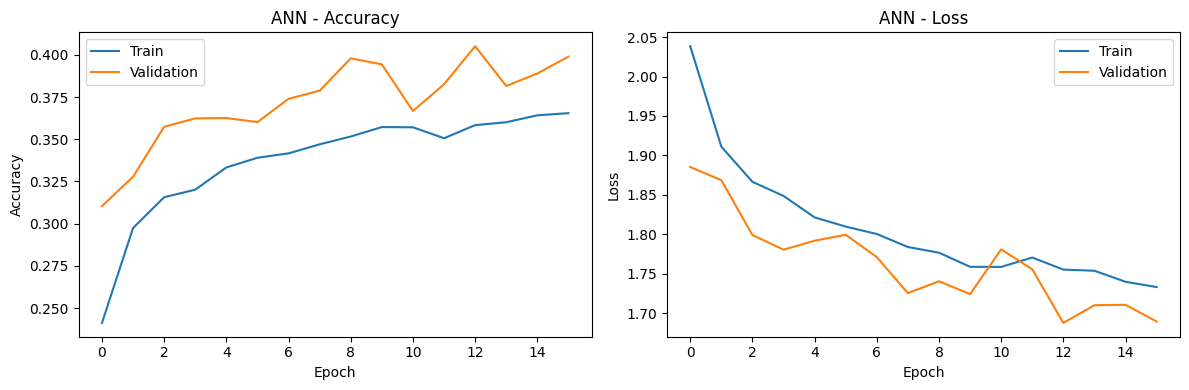

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ann_history.history['accuracy'], label='Train')
axes[0].plot(ann_history.history['val_accuracy'], label='Validation')
axes[0].set_title("ANN - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(ann_history.history['loss'], label='Train')
axes[1].plot(ann_history.history['val_loss'], label='Validation')
axes[1].set_title("ANN - Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

The ANN plateaus fairly quickly and there's a noticeable gap between training and validation accuracy, indicating it's starting to overfit even with dropout. Without spatial awareness, the model can't really generalize well to new images.

## Part 2: CNN Model

CNN uses convolutional filters to detect local patterns like edges, textures, and shapes. It preserves spatial relationships which is exactly what's needed for image tasks. The architecture goes from simple to complex features as we go deeper.

### Build and Train CNN

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='CNN')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699,050 (2.67 MB)

 Trainable params: 698,602 (2.66 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stop_cnn = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_cnn, reduce_lr],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 309s 433ms/step - accuracy: 0.4117 - loss: 1.6154 - val_accuracy: 0.5642 - val_loss: 1.2033 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 301s 428ms/step - accuracy: 0.5769 - loss: 1.1829 - val_accuracy: 0.6496 - val_loss: 0.9906 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 301s 427ms/step - accuracy: 0.6592 - loss: 0.9744 - val_accuracy: 0.6504 - val_loss: 1.0042 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 322s 427ms/step - accuracy: 0.7012 - loss: 0.8593 - val_accuracy: 0.6606 - val_loss: 0.9821 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 301s 428ms/step - accuracy: 0.7310 - loss: 0.7730 - val_accuracy: 0.7228 - val_loss: 0.8187 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 304s 432ms/step - accuracy: 0.7535 - loss: 0.7082 - val_accuracy: 0.7682 - val_loss: 0.6764 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 303s 430ms/step - accura

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

CNN Test Loss: 0.5708
CNN Test Accuracy: 0.8099


### CNN Training Curves

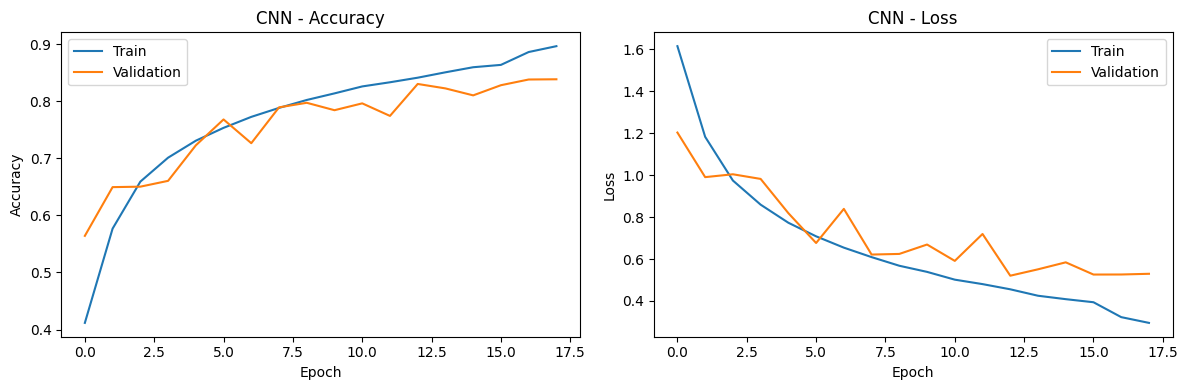

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cnn_history.history['accuracy'], label='Train')
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation')
axes[0].set_title("CNN - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(cnn_history.history['loss'], label='Train')
axes[1].plot(cnn_history.history['val_loss'], label='Validation')
axes[1].set_title("CNN - Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

The CNN learns much faster and reaches higher accuracy than the ANN. The training and validation curves stay relatively close, meaning the model is generalizing better. Batch normalization and dropout together are helping keep overfitting in check.

## Part 3: CNN with Data Augmentation

Data augmentation artificially expands the training set by applying random transformations to images. The model sees slightly different versions of each image every epoch, which improves generalization especially on a relatively small dataset like CIFAR-10.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
], name='augmentation')

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='CNN_Augmented')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

Model: "CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop_aug = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_aug = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug, reduce_lr_aug],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 330s 461ms/step - accuracy: 0.3095 - loss: 1.8899 - val_accuracy: 0.4274 - val_loss: 1.5193 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 328s 466ms/step - accuracy: 0.4074 - loss: 1.6135 - val_accuracy: 0.2970 - val_loss: 2.0607 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 381s 464ms/step - accuracy: 0.4630 - loss: 1.4723 - val_accuracy: 0.4754 - val_loss: 1.4811 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 376s 456ms/step - accuracy: 0.5040 - loss: 1.3703 - val_accuracy: 0.5776 - val_loss: 1.1787 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 321s 456ms/step - accuracy: 0.5348 - loss: 1.2981 - val_accuracy: 0.4906 - val_loss: 1.5306 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 321s 457ms/step - accuracy: 0.5655 - loss: 1.2240 - val_accuracy: 0.5638 - val_loss: 1.2363 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 320s 454ms/step - accura

In [17]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Test Loss: {aug_test_loss:.4f}")
print(f"Augmented CNN Test Accuracy: {aug_test_acc:.4f}")

Augmented CNN Test Loss: 0.8401
Augmented CNN Test Accuracy: 0.7187


### Augmented CNN Training Curves

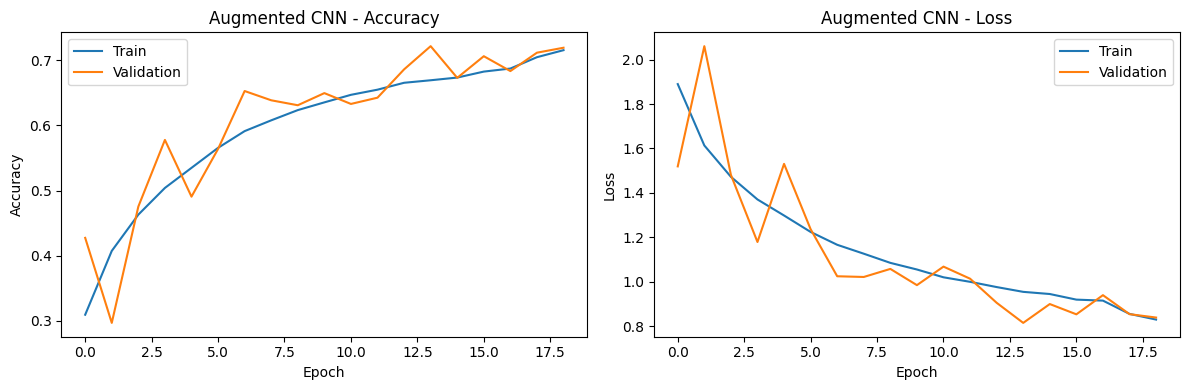

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(aug_history.history['accuracy'], label='Train')
axes[0].plot(aug_history.history['val_accuracy'], label='Validation')
axes[0].set_title("Augmented CNN - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(aug_history.history['loss'], label='Train')
axes[1].plot(aug_history.history['val_loss'], label='Validation')
axes[1].set_title("Augmented CNN - Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

As per norms the data augmentation helps model to learn more generalise knowledge it flips, rotations, and zooms the image dataset in this case and it helps the network generalize better and prevents it from memorizing the exact training data, which reduces overfitting. But in our case generally we used very low patience parameter of 5 and 20 epochs only, which is the reason the CNN with data augmentation is not performing as it should have, it didn't get enough epoch to train on, otherwise with 30 or 40 epoch it can do much better.

## Comparison Across Architectures

Bringing all three models together to see how they stack up.

### Validation Accuracy Curves

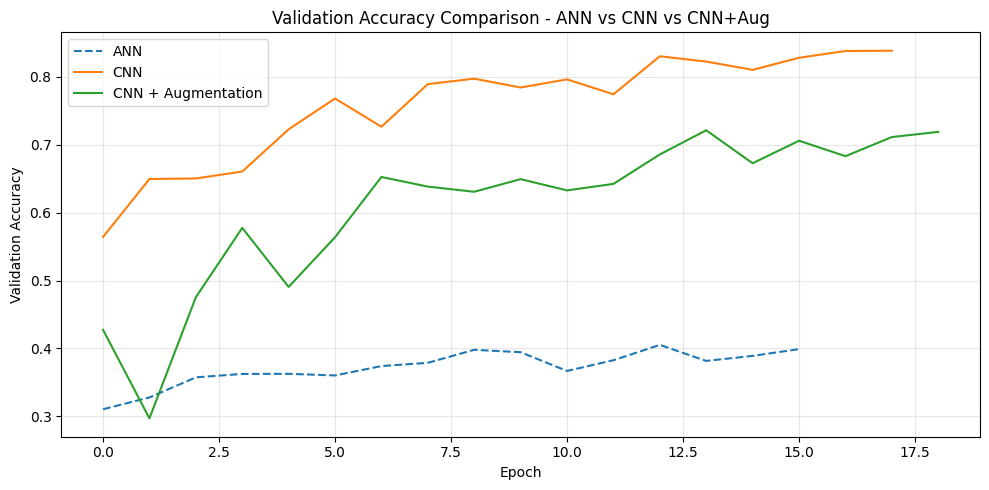

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(ann_history.history['val_accuracy'], label='ANN', linestyle='--')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(aug_history.history['val_accuracy'], label='CNN + Augmentation')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison - ANN vs CNN vs CNN+Aug")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final Performance Table

In [20]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss]
})

comparison["Test Accuracy (%)"] = (comparison["Test Accuracy"] * 100).round(2)
comparison = comparison.drop(columns=["Test Accuracy"])

print(comparison.to_string(index=False))

             Model  Test Loss  Test Accuracy (%)
               ANN   1.668449              41.21
               CNN   0.570760              80.99
CNN + Augmentation   0.840135              71.87


### Model Size Comparison

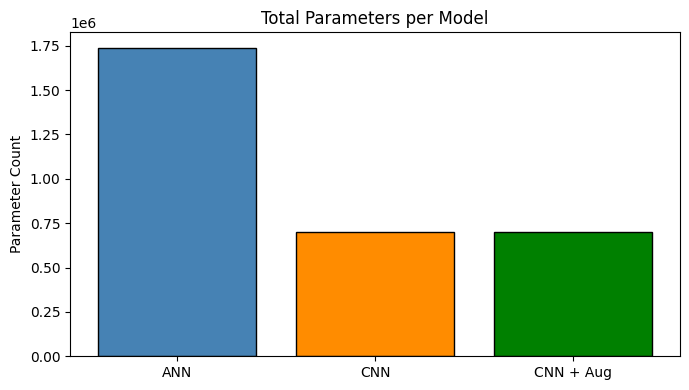

ANN: 1,738,890 parameters
CNN: 699,050 parameters
CNN + Aug: 699,050 parameters


In [21]:
def count_params(model):
    return model.count_params()

param_counts = {
    'ANN': count_params(ann_model),
    'CNN': count_params(cnn_model),
    'CNN + Aug': count_params(aug_cnn_model)
}

plt.figure(figsize=(7, 4))
plt.bar(param_counts.keys(), param_counts.values(), color=['steelblue', 'darkorange', 'green'], edgecolor='black')
plt.title("Total Parameters per Model")
plt.ylabel("Parameter Count")
plt.tight_layout()
plt.show()

for name, count in param_counts.items():
    print(f"{name}: {count:,} parameters")

## Detailed Evaluation - Best Model

Running a per-class breakdown on the best performing model to see which classes are hardest to classify.

In [22]:
y_pred_cnn = np.argmax(cnn_model.predict(x_test_norm, verbose=0), axis=1)
y_true = y_test.ravel()

print("Classification Report (CNN):")
print(classification_report(y_true, y_pred_cnn, target_names=class_names))

Classification Report (CNN):
              precision    recall  f1-score   support

    airplane       0.81      0.82      0.82      1000
  automobile       0.94      0.87      0.91      1000
        bird       0.80      0.68      0.74      1000
         cat       0.69      0.62      0.66      1000
        deer       0.71      0.86      0.78      1000
         dog       0.78      0.71      0.74      1000
        frog       0.78      0.91      0.84      1000
       horse       0.86      0.85      0.85      1000
        ship       0.84      0.91      0.88      1000
       truck       0.91      0.86      0.88      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



### Confusion Matrix

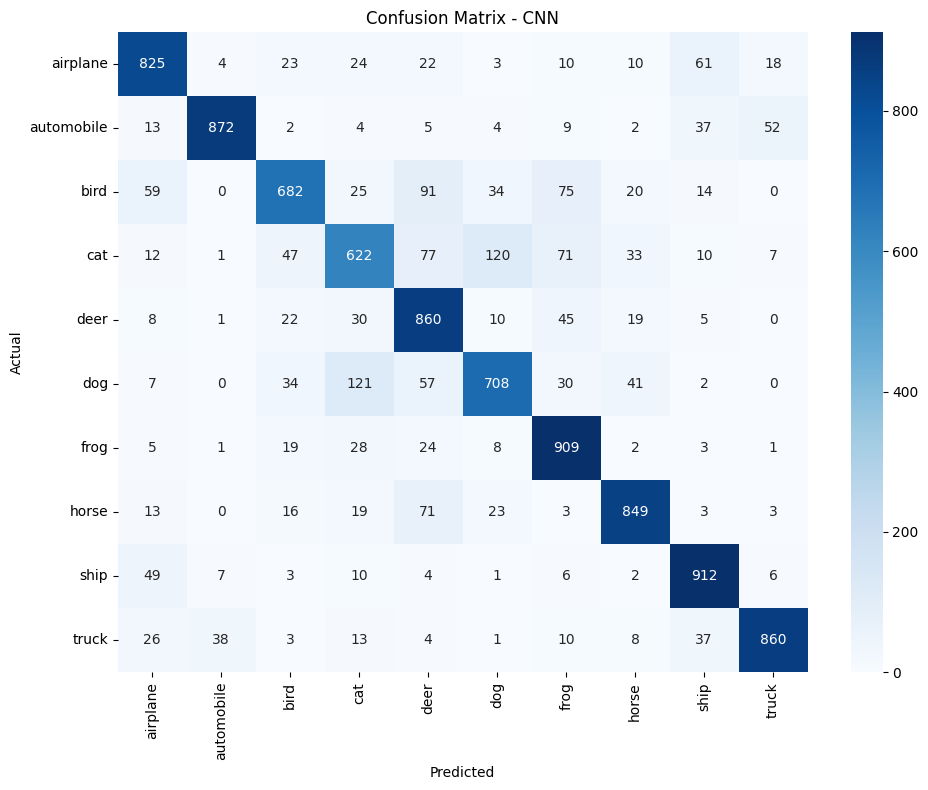

In [23]:
cm = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Looking at the confusion matrix, the most common mistakes happen between visually similar classes - cat vs dog, deer vs horse, automobile vs truck. That makes sense given the small image size and similar visual features between those pairs.

### Misclassified Samples

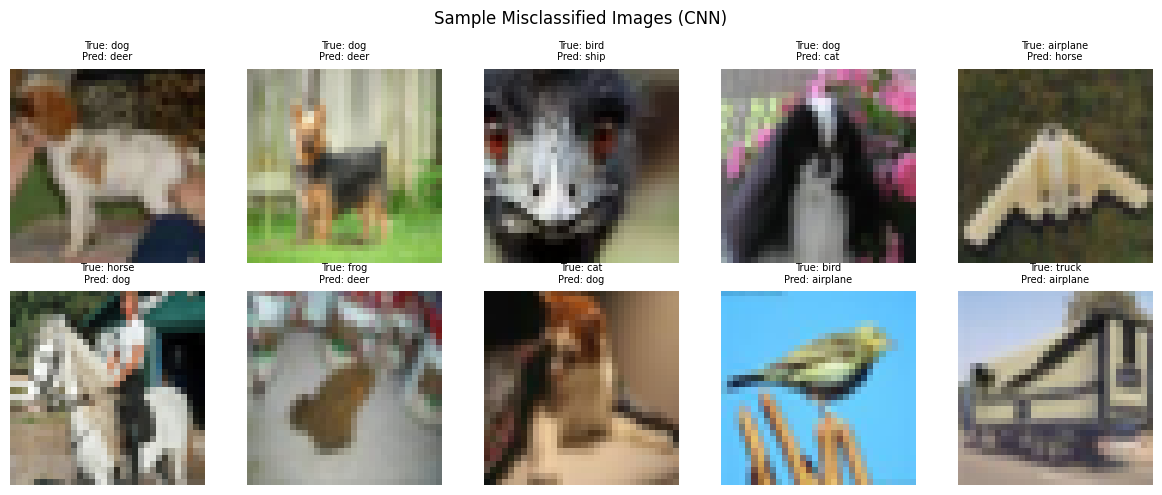

In [24]:
misclassified = np.where(y_pred_cnn != y_true)[0]

plt.figure(figsize=(12, 5))
for i, idx in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_norm[idx])
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_cnn[idx]]}", fontsize=7)
    plt.axis("off")
plt.suptitle("Sample Misclassified Images (CNN)", fontsize=12)
plt.tight_layout()
plt.show()

Even for a human some of these would be tricky at 32x32 resolution. The misclassifications mostly happen in blurry or ambiguous images where distinguishing features aren't clear.

## Conclusion

**Key Takeaways:**

- The **ANN** can learn the classification task to some extent but plateaus early. Flattening the image loses all spatial information, which is a fundamental limitation.

- The **CNN** significantly outperforms the ANN by preserving and exploiting spatial structure through convolutional filters. The improvement in accuracy is substantial with fewer parameters dedicated to actual classification.

- **Data Augmentation** further improves generalization. The model becomes more robust to image variations it wasn't directly trained on.

- Adding **EarlyStopping** and **ReduceLROnPlateau** callbacks made training cleaner - the models stop when they stop improving instead of overfitting past the optimal point.

- The hardest classes to classify are visually similar ones like cat/dog and automobile/truck, which is expected given the 32x32 resolution.

The overall conclusion is straightforward: for image data, CNNs are the right tool. ANNs are fine for tabular data but lose too much structural information when applied to images.